<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/medium_mslp_wind200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="output_png output_subarea output_execute_result">
<center>
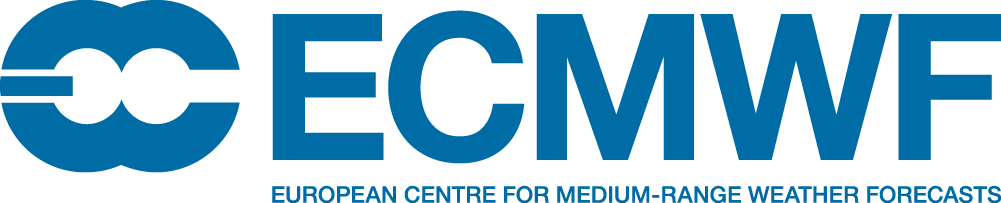
</div>

# 	Mean sea level pressure and wind at 200 hPa

This notebook will provide you guidance how to explore and plot ECMWF open dataset to produce the map from the ECMWF open charts web product.  
The original product can be found on this link: https://charts.ecmwf.int/products/medium-mslp-wind200  


<div class="output_png output_subarea output_execute_result">
<center>
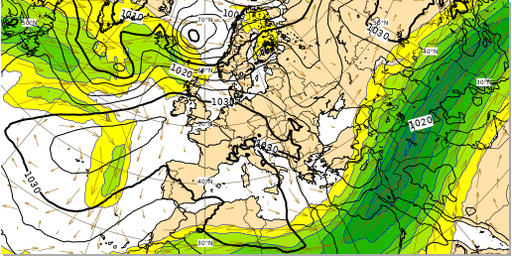</center>
</div>

The full list of available Open data products can be found [here](https://www.ecmwf.int/en/forecasts/datasets/open-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF Open data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain the access to the full forecast dataset at higher resolution please visit our [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes in input 3 parameters :

* [Mean sea level pressure](https://codes.ecmwf.int/grib/param-db/151)
* [U component of wind at 200 hPa](https://codes.ecmwf.int/grib/param-db/131)
* [V component of wind  at 200 hPa](https://codes.ecmwf.int/grib/param-db/132)

In this example, we will use:
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data

First we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on three dots below, uncomment the code and run the next two cells.
</div>

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install() # expect a kernel restart


In [ ]:
!pip install ecmwf-opendata

In [ ]:
!conda install metview metview-python

In [ ]:
import metview as mv
from ecmwf.opendata import Client

Great — let’s go step-by-step in English as you asked. Here’s what those two lines do and how they fit together.

**`import metview as mv`**

* Imports the **Metview** Python API and gives it the short name `mv`.
* Metview is a toolkit (with a C++ core and Python bindings) made by ECMWF to **read, process and visualise meteorological fields** (GRIB, NetCDF, etc.).
* Typical capabilities you’ll use:

  * read data: `mv.read("file.grib")`
  * create plotting descriptors (not the plot itself): `mv.mcont(...)`, `mv.mwind(...)`, `mv.geoview(...)`, `mv.mtext(...)`
  * configure output: `mv.setoutput('jupyter', width=..., height=...)`
  * render the plot: `mv.plot(view, field, style, ...)` — this is when descriptor objects are evaluated and the image is produced.
* Important behavior: many `mv.*` calls return **descriptor objects** (settings). Nothing is drawn until you call `mv.plot()` (or explicitly read/execute a field).

**`from ecmwf.opendata import Client`**

* Imports the `Client` class from the `ecmwf-opendata` package.
* Purpose: programmatic access to ECMWF’s **OpenData** content — it constructs the correct URLs and downloads forecast/analysis GRIBs or other files from ECMWF servers.
* Main usage pattern:

  * create a client: `client = Client()`
  * request a file: `client.retrieve(date=..., time=..., step=..., stream=..., param=..., target="out.grib")`
  * the method builds the HTTP request, downloads the file and writes it to `target`.
* Failure modes you’ve already seen: if the requested file doesn’t exist on the server the client will raise an HTTP error (404). Also pay attention to parameter types (e.g. `time` is typically an integer hour like `0`, `6`, `12`, `18`).

**How they work together (typical workflow)**

1. Use `Client` to download a GRIB file to disk.
2. Use Metview to read that file and create plot descriptors.
3. Call `mv.plot(...)` to render the map (in a Jupyter cell or a file).


In [ ]:
client = Client("ecmwf", beta=False)

That line is creating an **ECMWF OpenData client object** with two specific settings:


### 1️`"ecmwf"`

* This is the **data source identifier**.
* The `Client` class in `ecmwf-opendata` can point to different back-ends (for example: `"ecmwf"` for ECMWF’s own operational forecast service, `"azure"` for the Microsoft-hosted copy, `"aws"` for the Amazon-hosted copy, `"cds"` for Copernicus, etc.).
* By passing `"ecmwf"`, you’re telling it:

  > “Use ECMWF’s **own servers** ([https://data.ecmwf.int](https://data.ecmwf.int)) to get the files.”



### 2️`beta=False`

* ECMWF sometimes runs a **beta** version of their OpenData service with early access to products, new formats, or experimental changes.
* If you set `beta=True`, the client would point to the beta endpoints (often a different directory structure or file naming).
* With `beta=False`, you’re explicitly saying:

  > “Use the **production** service, not the beta/testing one.”


### What happens internally

When you run that line:

1. The `Client` constructor saves those settings in the object.
2. It builds internal URL templates based on the chosen source (`"ecmwf"`) and version (`beta` flag).
3. Later, when you call `client.retrieve(...)`, it fills those templates with your `date`, `time`, `step`, etc., to generate the correct URL for the file you want.




## Retrieve requests
This product uses parameters at different vertical levels.  
Mean sea level pressure belongs to the surface parameters, while u and v at 200 hPa are pressure level parameters.  
The two types of levels can not be in the same request, so we need to make two requests for them.

* These are **lists of parameter short names** from the ECMWF parameter table.
* `sfc_parameters` → for **surface fields** (`sfc` = surface), here only `"msl"` = mean sea level pressure.
* `pl_parameters` → for **pressure level fields** (`pl` = pressure levels), here `"u"` and `"v"` = the eastward and northward wind components.
* When you later pass `param=sfc_parameters` or `param=pl_parameters` into `client.retrieve(...)`, the client will request *all* those parameters in a single GRIB file.
* These are just **strings holding file names** for the downloaded GRIB files.
* `sfc_filename` → where the surface parameters will be saved.
* `pl_filename` → where the pressure level parameters will be saved.
* This separation means you can download and store them independently (surface vs. upper air) without overwriting one file.

### **Why do it this way?**

1. **Clarity** – You can see at a glance which parameters you’re requesting for each type of level.
2. **Reusability** – You can pass these lists and filenames into `client.retrieve()` multiple times without retyping them.

   ```python
   client.retrieve(date=..., levtype='sfc', param=sfc_parameters, target=sfc_filename)
   client.retrieve(date=..., levtype='pl', levelist=200, param=pl_parameters, target=pl_filename)
   ```
3. **Efficiency** – ECMWF lets you request multiple parameters in the same file if they share the same metadata (date, time, step, level type, etc.), so grouping them like this saves you separate downloads.



In [ ]:
sfc_parameters = ['msl']
pl_parameters = ['u', 'v']
sfc_filename = 'medium-mslp-wind200-sfc.grib'
pl_filename = 'medium-mslp-wind200-pl.grib'

Next code is telling the ECMWF OpenData client:

---

### **What it’s requesting**

* **`date=0`**
  In the `ecmwf-opendata` package, passing `0` as the date is a shortcut meaning

  > “Use **today’s date** in UTC.”
  > It will internally replace it with the current date in `YYYY-MM-DD` format.

* **`time=0`**
  Here `0` means

  > “Use the **00 UTC run** of the forecast.”
  > This must be an integer hour: 0, 6, 12, or 18 for ECMWF operational forecasts.

* **`step=12`**
  Forecast lead time (in hours) from the model start time.
  Here: 12 hours after the run start.

* **`stream="oper"`**
  Tells ECMWF you want the operational (high-resolution) forecast, not an ensemble or other stream.

* **`type="fc"`**
  Means **forecast** data (as opposed to `"an"` = analysis).

* **`levtype="sfc"`**
  Means surface level data (not pressure levels).

* **`param=sfc_parameters`**
  The list we defined earlier, here `['msl']` = mean sea level pressure.

* **`target=sfc_filename`**
  Where to save the GRIB file — here `'medium-mslp-wind200-sfc.grib'`.


>### **Why `0` and `0`?**
>
>* It’s a convenience feature — you don’t need to manually type `"2025-08-12"` or guess the latest date.
* You only use this safely if you know **today’s 00 UTC run** is already published and complete.
  If you run this too soon after model start, ECMWF may not have all `step=12` files ready yet, and you’ll get the 404 error you saw before.



Example with explicit date/time (same as above but without shortcuts):

```python
client.retrieve(
    date="2025-08-12",
    time=0,
    step=12,
    stream="oper",
    type="fc",
    levtype="sfc",
    param=['msl'],
    target='medium-mslp-wind200-sfc.grib'
)
```

---

If you want, I can show you how to make `date` and `time` **auto-select the most recent available run** instead of hard-coding `0,0` or a fixed date, so you never hit missing data errors. That’s what meteorological scripts normally do for operational workflows.



Setting date to 0 will download today's data.
Removing date and time altogether from the request will download the latest data.  
Try commenting out date and time to download latest forecast!

In [ ]:
client.retrieve(
    date=0,
    time=0,
    step=12,
    stream="oper",
    type="fc",
    levtype="sfc",
    param=sfc_parameters,
    target=sfc_filename
)

In [ ]:
client.retrieve(
    date=0,
    time=0,
    step=12,
    stream="oper",
    type="fc",
    levtype="pl",
    levelist=200,
    param=pl_parameters,
    target=pl_filename
)

### How it works

* **`for hours_back in range(0, 48, 6)`** → tries 0h ago, 6h ago, 12h ago, … up to 48h ago.
* **`hour = dt.hour - (dt.hour % 6)`** → ECMWF runs only start at 0, 6, 12, 18 UTC; this rounds down to the nearest one.
* In each loop, it:

  1. Downloads the surface GRIB.
  2. Downloads the pressure-level GRIB.
  3. If both succeed, it stops and returns the date/hour.
* If either fails, it moves to the next earlier run.

---

If you want, I can add a **`print()` status line for each attempt**, so you can see exactly which runs are being tested until one works. That way you’ll know how far back it had to go.

Do you want me to add that logging?


## Reading and processing the data
Now we can use **Metview's read() function** to read the files.

In [ ]:
from datetime import datetime, timedelta
from ecmwf.opendata import Client

def latest_run():
    # Loop backwards in 6-hour steps, max 48h back
    for hours_back in range(0, 48, 6):
        dt = datetime.utcnow() - timedelta(hours=hours_back)
        date_str = dt.strftime("%Y-%m-%d")
        hour = dt.hour - (dt.hour % 6)  # round down to nearest 6h

        try:
            # --- Surface fields ---
            client.retrieve(
                date=date_str,
                time=hour,
                step=12,
                stream="oper",
                type="fc",
                levtype="sfc",
                param=sfc_parameters,
                target=sfc_filename
            )

            # --- Pressure level fields ---
            client.retrieve(
                date=date_str,
                time=hour,
                step=12,
                stream="oper",
                type="fc",
                levtype="pl",
                levelist=200,
                param=pl_parameters,
                target=pl_filename
            )

            print(f"✅ Data found for {date_str} {hour:02d} UTC")
            return date_str, hour  # stop after both succeed

        except Exception as e:
            # If *either* retrieval fails, try the previous run
            continue

    # If we finish the loop without finding any
    raise RuntimeError("❌ No valid run found in the last 48 hours.")

# Create the ECMWF client
client = Client(source="ecmwf")

# Call the function
date_found, hour_found = latest_run()



Those two lines are **Metview** reading the GRIB files you just downloaded with `client.retrieve()`.


* `mv.read()` is Metview’s function for **loading meteorological data files** (GRIB, NetCDF, BUFR, etc.) into a Python object that Metview can work with.
* Here `pl_filename` is `'medium-mslp-wind200-pl.grib'` (from your earlier variable definition).
* This GRIB contains:
  * Variables `"u"` and `"v"` at 200 hPa (from `pl_parameters = ['u', 'v']`).
  * They represent the **eastward (u)** and **northward (v)** wind components.
* The result, `wind200`, is a **Metview Fieldset** object — essentially a list of GRIB fields you can filter, style, and plot.
* `sfc_filename` is `'medium-mslp-wind200-sfc.grib'`.
  * This file contains `"msl"` = mean sea level pressure.
  * `msl` is also a Fieldset object.



* `client.retrieve()` just downloads files to disk — it doesn’t load them into memory.
* Metview needs the data in a Fieldset object to work with plotting commands like `mv.plot()`, `mv.mcont()`, `mv.mwind()`, etc.
* After `mv.read()`, you can:

  * Plot them directly:

    ```python
    mv.plot(msl)
    ```
  * Combine them with styles:

    ```python
    mv.plot(view, msl, mslp_contour, wind200, wind_arrows)
    ```
  * Filter or subset:

    ```python
    mv.read(sfc_filename, parameter='msl')
    ```

---

In other words — those two lines are the bridge between **files on disk** and **Metview’s in-memory plotting objects**.

If you want, next I can explain **how Metview knows which fields are which inside `wind200`** and how to extract, for example, just the `"u"` or just the `"v"` field for plotting. Would you like me to?


In [ ]:
wind200 = mv.read(pl_filename)
msl = mv.read(sfc_filename)

In [ ]:
 mv.plot(msl)

In [ ]:
import metview as mv

# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# Definir la vista de Europa y el estilo de las isobaras
view_europe = mv.geoview(
    map_area_definition="corners",
    area=[30, -20, 70, 40],  # Europa: [lat_min, lon_min, lat_max, lon_max]
    coastlines=coast,
)


# mostrar gráfico
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view_europe, msl)

The **describe()** function will give us the overview of the dataset.  

In [ ]:
wind200.describe()

And an overview of one parameter, where we can see more information, such as units or type of level.

In [ ]:
msl.describe('msl')

We can use **ls()** function to list all the fields in the file we downloaded.

In [ ]:
wind200.ls()

In order to calculate the speed, we need to filter out u and v component and use the **speed()** function for the calculation.

In [ ]:
u = wind200.select(shortName ='u')
v = wind200.select(shortName ='v')
speed = mv.speed(u,v)
speed.describe()

Mean sea level pressure data has unites Pa, but we want to plot it in hPa, therefore we need to convert it.

In [ ]:
msl /= 100

And finally, we can plot the data on the map.

In [ ]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
# Definir la vista de Europa y el estilo de las isobaras
view = mv.geoview(
    map_area_definition="corners",
    area=[30, -20, 70, 40],  # Europa: [lat_min, lon_min, lat_max, lon_max]
    coastlines=coast,
)

#define styles
speed_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_grn_f30t100i10")

mslp_contour = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "ct_blk_i5_t2")

wind_arrows = mv.mwind(
    wind_thinning_factor=5, wind_arrow_colour="mustard"
)

title = mv.mtext(
    text_lines=["Mean sea level pressure and wind at 200 hPa",
                "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H' where='shortName=msl' /> ",
                "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H' where='shortName=msl' />, STEP: <grib_info key='step' where='shortName=msl' />"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, speed, speed_shade, wind200, wind_arrows, msl, mslp_contour, title, ecmwf_text)




To generate the png file you can run the following cell.

In [ ]:
png = mv.png_output(
      output_name = "medium-mslp-wind200",   # specify relative or full path
      output_title = "medium-mslp-wind200",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, speed, speed_shade, wind200, wind_arrows, msl, mslp_contour, title, ecmwf_text)

Note that plot produced using open data dataset will slightly differ from one from Open Charts. This is due to different resolution of the data.  
Open data is on 0.25x0.25 resolution, while high resolution data is 0.1x0.1 grid.